In [1]:
!date

Wed Sep 11 17:24:40 PDT 2024


In [2]:
%load_ext autoreload
%load_ext line_profiler

In [3]:
import logging
logging.basicConfig(level=logging.INFO, force=True)

In [4]:
import os as _os
_os.chdir(_os.environ['PROJECT_ROOT'])

In [5]:
import graph_tool as gt
import graph_tool.draw
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
from contextlib import contextmanager
import xarray as xr
from itertools import product
from functools import partial
from tqdm import tqdm
from itertools import chain
from graph_tool.util import find_edge
import scipy as sp

from tqdm import tqdm

import strainzip as sz
from strainzip.pandas_util import idxwhere
import strainzip.app.unzip

from multiprocessing import Pool as processPool
import pickle

In [14]:
pool = processPool(processes=10)

In [7]:
sz.depth_model.NAMED_DEPTH_MODELS

{'OffsetLogNormal': (strainzip.depth_model._offset_log_normal.OffsetLogNormalDepthModel,
  {'alpha': 1.0, 'maxiter': 10000}),
 'Normal': (strainzip.depth_model._normal.NormalDepthModel,
  {'maxiter': 10000, 'tol': 0.0001}),
 'NormalScaled2': (strainzip.depth_model._normal_scaled2.NormalScaled2DepthModel,
  {'alpha': 1.0, 'maxiter': 1000, 'tol': 0.001}),
 'NormalScaled3': (strainzip.depth_model._normal_scaled3.NormalScaled3DepthModel,
  {'alpha': 0.5, 'maxiter': 1000, 'tol': 0.001}),
 'NormalPooled': (strainzip.depth_model._normal_pooled.NormalPooledDepthModel,
  {'maxiter': 10000}),
 'Laplace': (strainzip.depth_model._laplace.LaplaceDepthModel,
  {'maxiter': 10000}),
 'LaplacePooled': (strainzip.depth_model._laplace_pooled.LaplacePooledDepthModel,
  {'maxiter': 10000}),
 'StudentsT': (strainzip.depth_model._studentst.StudentsTDepthModel,
  {'df': 5, 'maxiter': 10000}),
 'Huber': (strainzip.depth_model._huber.HuberDepthModel,
  {'delta': 1, 'maxiter': 10000}),
 'Default': (strainzip.dep

In [ ]:
%%time

with open('data/group/xjin/r.proc.ggcat-k111-withmegahit3-droptips.notips-2.smoothed-6.unzip-norm-10-10.checkpoints.d/junctions_safe_1.pkl', 'rb') as f:
    problems = pickle.load(f)
print(len(problems))

In [11]:
for p in tqdm(problems):
    if np.isnan(p.in_flows).any():
        break
else:
    print("no nans")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6432/6432 [00:00<00:00, 268472.86it/s]

no nans


In [12]:
model = sz.depth_model.NormalDepthModel(maxiter=1000, tol=1e-4)

print(model)
_, results = sz.app.unzip._run_calculate_junction_deconvolutions(problems[slice(None)], depth_model=model, mapping_func=map, score_name='aic')

NormalDepthModel(maxiter=1000, tol=0.0001)


  0%|| 0/6432 [00:00<?, ?it/s, converged=0, best=0, complete=0, minimal=0, identifiable=0, split=0]INFO:jax._src.xla_bridge:Unable to initialize backend 'cuda': 
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
100%|| 6432/6432 [02:23<00:00, 44.75it/s, converged=6344, best=6344, complete=6344, minimal=6344, identifiable=6344, split=6344]


In [15]:
model = sz.depth_model.NormalDepthModel(maxiter=1000, tol=1e-4)

print(model)
_, results = sz.app.unzip._run_calculate_junction_deconvolutions(problems[slice(None)], depth_model=model, mapping_func=pool.imap_unordered, score_name='aic')

NormalDepthModel(maxiter=1000, tol=0.0001)


100%|| 6432/6432 [00:18<00:00, 338.62it/s, converged=6344, best=6344, complete=6344, minimal=6344, identifiable=6344, split=6344]


In [12]:
print("done")

done


3 3


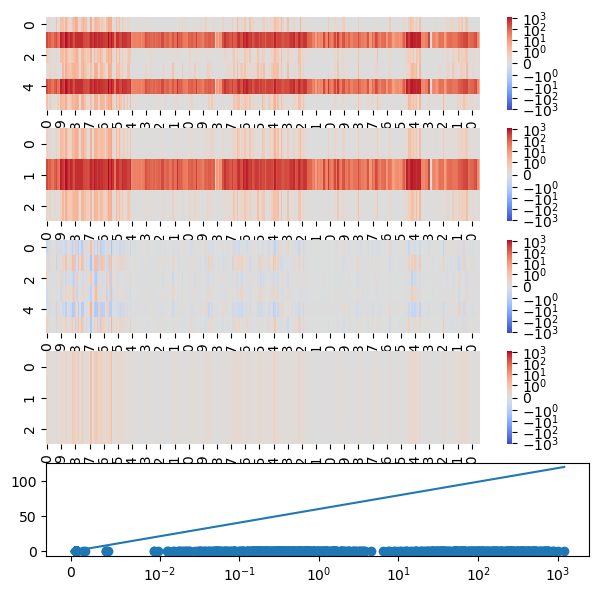

In [213]:
j = 2
prob = problems[j]
res = results[j]
fit = res.fit

print(len(prob.in_neighbors), len(prob.out_neighbors))
# n, m = len(_problem.in_neighbors), len(_problem.out_neighbors)
# print(n, m)

# Y = np.concatenate([_problem.in_flows, _problem.out_flows])

# pathset = sz.deconvolution.PathSet(frozenset([
#     sz.deconvolution.LocalPath(0, 1), sz.deconvolution.LocalPath(1, 0), # Most obvious
#     # sz.deconvolution.LocalPath(2, 0),  # Excess
# ]), n=n, m=m)
# X = sz.deconvolution.pathset_to_design(pathset)
# print(X, Y.shape)

vmax = fit.y.max()

fig, axs = plt.subplots(5, figsize=(7, 7))
sns.heatmap(fit.y, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[0])
sns.heatmap(fit.beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[1])
sns.heatmap(fit.residual, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[2])
sns.heatmap(fit.stderr_beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[3])
axs[4].scatter(fit.beta, fit.stderr_beta)
axs[4].plot([0, vmax], [0, vmax / 10])
axs[4].set_xscale('symlog', linthresh=1e-2)

In [253]:
%autoreload

In [254]:
model2 = sz.depth_model.NormalScaled3DepthModel(maxiter=10000, tol=1e-3, alpha=1/2)
fit2 = model2.fit(res.fit.y, res.fit.X)

In [255]:
np.sum(fit2.model.grad_beta(**fit2.params, y=fit2.y, X=fit2.X)**2)

Array(1.70279509e+14, dtype=float64)

3 3


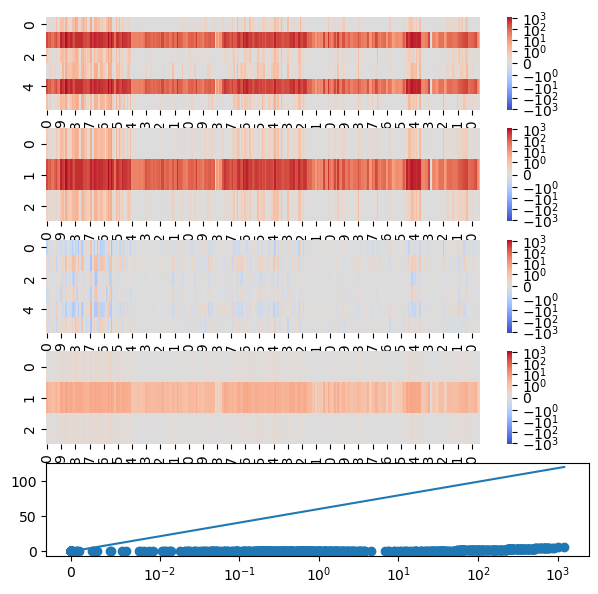

In [227]:
fit = fit2

print(len(prob.in_neighbors), len(prob.out_neighbors))
# n, m = len(_problem.in_neighbors), len(_problem.out_neighbors)
# print(n, m)

# Y = np.concatenate([_problem.in_flows, _problem.out_flows])

# pathset = sz.deconvolution.PathSet(frozenset([
#     sz.deconvolution.LocalPath(0, 1), sz.deconvolution.LocalPath(1, 0), # Most obvious
#     # sz.deconvolution.LocalPath(2, 0),  # Excess
# ]), n=n, m=m)
# X = sz.deconvolution.pathset_to_design(pathset)
# print(X, Y.shape)

vmax = fit.y.max()

fig, axs = plt.subplots(5, figsize=(7, 7))
sns.heatmap(fit.y, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[0])
sns.heatmap(fit.beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[1])
sns.heatmap(fit.residual, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[2])
sns.heatmap(fit.stderr_beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[3])
axs[4].scatter(fit.beta, fit.stderr_beta)
axs[4].plot([0, vmax], [0, vmax / 10])
axs[4].set_xscale('symlog', linthresh=1e-2)

In [252]:
from jax import grad

llk = lambda beta, sigma: fit.model.loglik(beta=beta, sigma=sigma, y=fit.y, X=fit.X)
grad_llk = grad(llk, argnums=[0, 1])

grad_beta, grad_sigma = grad_llk(fit.params['beta'], fit.params['sigma'])
np.sum(grad_beta ** 2)

Array(1.70279509e+14, dtype=float64)

In [323]:
res.score_margin

7.209600475400293

In [324]:
res

DeconvolutionResult(converged=Array(True, dtype=bool, weak_type=True), score_margin=7.209600475400293, completeness_ratio=1.0, excess_paths=0, relative_stderr=array([[4.04293345e-04, 2.82532856e-04, 6.66004126e-04, 2.32364022e-04,
        5.50460348e-04, 3.60388109e-04, 2.31141264e-04, 5.10903561e-04,
        7.74457038e-04, 2.04378625e-03, 7.85502967e-06, 7.85502967e-06,
        7.85502967e-06, 7.85502967e-06, 7.85502967e-06, 7.85502967e-06,
        7.85502967e-06],
       [1.81845815e-01, 1.78959496e-01, 2.44451313e-01, 9.95509325e-02,
        3.62215863e-01, 1.02974360e-01, 6.60129269e-02, 6.61184953e-02,
        5.96649105e-01, 1.76427282e-01, 7.85502967e-06, 7.85502967e-06,
        7.85502967e-06, 7.85502967e-06, 7.85502967e-06, 7.85502967e-06,
        7.85502967e-06],
       [1.25864680e-01, 6.56384202e-02, 1.36976912e-01, 3.87918281e-02,
        1.52624118e-01, 7.20528848e-02, 4.01117833e-02, 5.31079588e-02,
        1.57422222e-01, 1.21666590e-01, 6.80267653e-06, 6.80267653e-06,

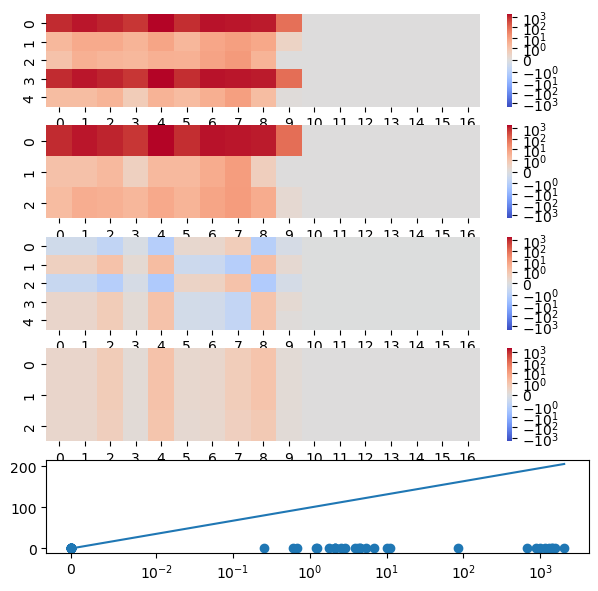

In [321]:
j = 2
res = results[1][j]
fit = res.fit

# n, m = len(_problem.in_neighbors), len(_problem.out_neighbors)
# print(n, m)

# Y = np.concatenate([_problem.in_flows, _problem.out_flows])

# pathset = sz.deconvolution.PathSet(frozenset([
#     sz.deconvolution.LocalPath(0, 1), sz.deconvolution.LocalPath(1, 0), # Most obvious
#     # sz.deconvolution.LocalPath(2, 0),  # Excess
# ]), n=n, m=m)
# X = sz.deconvolution.pathset_to_design(pathset)
# print(X, Y.shape)

vmax = fit.y.max()

fig, axs = plt.subplots(5, figsize=(7, 7))
sns.heatmap(fit.y, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[0])
sns.heatmap(fit.beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[1])
sns.heatmap(fit.residual, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[2])
sns.heatmap(fit.stderr_beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-vmax, vmax=vmax), ax=axs[3])
axs[4].scatter(fit.beta, fit.stderr_beta)
axs[4].plot([0, vmax], [0, vmax / 10])
axs[4].set_xscale('symlog', linthresh=1e-2)

In [202]:
print(model)

_fit = model.fit(Y, X)
_fit.debug['opt']['grad_norm']

NormalDepthModel(maxiter=1000, tol=0.0001)


TypeError: tuple indices must be integers or slices, not str

In [196]:
_fit.debug['opt']#['beta_grad']

{'converged': False,
 'grad_norm': Array(1391.15647529, dtype=float64),
 'beta_grad': Array([[ 1.06581410e-14,  1.15463195e-14,  1.24344979e-14,
          0.00000000e+00,  0.00000000e+00,  1.15463195e-14,
          0.00000000e+00,  0.00000000e+00, -1.24344979e-14,
          1.17683641e-14,  1.37642854e-21,  0.00000000e+00,
          1.58818678e-22,  0.00000000e+00,  1.85288457e-22,
         -3.44107135e-22, -5.45260658e-27],
        [-1.06581410e-14,  5.32907052e-15,  0.00000000e+00,
         -1.77635684e-15,  5.77315973e-15,  0.00000000e+00,
          5.32907052e-15,  2.88657986e-15,  5.32907052e-15,
          0.00000000e+00,  0.00000000e+00,  4.23516474e-22,
          0.00000000e+00,  0.00000000e+00,  8.27180613e-25,
          2.64697796e-23, -2.52435490e-29]], dtype=float64),
 'sigma_grad': Array(1391.15647529, dtype=float64),
 'iter_num': 99}

In [183]:
_fit.loglik

Array(-305.36008943, dtype=float64)

In [188]:
_fit.model.loglik(beta=_fit.params['beta'], sigma=_fit.params['sigma'], y=_fit.y, X=_fit.X)

Array(-305.36008943, dtype=float64)

In [177]:
Y

array([[9.19548728e+00, 1.07978314e+01, 9.48453359e+00, 7.33315043e+00,
        6.97786050e+00, 1.09216551e+01, 1.72410833e+01, 6.40869793e+00,
        1.55845135e+01, 4.82651987e+00, 1.89931105e-06, 2.98962136e-06,
        2.17582375e-07, 9.39155386e-08, 1.77769016e-07, 2.45499899e-07,
        4.18012473e-12],
       [1.42436258e+01, 7.14341240e+00, 5.78199587e+00, 5.33194285e+00,
        5.26179890e+00, 4.70068141e+00, 9.84115295e+00, 4.09947397e+00,
        1.00649052e+01, 1.70664840e+00, 4.70355987e-11, 7.09246510e-11,
        5.54618537e-12, 2.31571394e-12, 4.26976626e-12, 2.55907504e-12,
        9.34015961e-18],
       [8.81537275e+00, 4.67507953e+00, 1.84859824e+00, 2.75228449e+00,
        5.01501282e+00, 3.47809931e+00, 6.21857668e+00, 3.78006413e+00,
        6.17118796e+00, 1.47625364e+00, 3.27348814e-07, 8.45523362e-07,
        6.51158337e-09, 9.02271952e-10, 1.66208039e-09, 3.99600722e-08,
        5.96190145e-14],
       [1.50579469e+01, 1.32304607e+01, 1.32656422e+01, 1.004

In [176]:
_fit.params

{'beta': Array([[1.21267171e+01, 1.20141461e+01, 1.13750879e+01, 8.68756682e+00,
         7.10403141e+00, 1.15643983e+01, 1.92703097e+01, 6.76528102e+00,
         1.78121602e+01, 5.03170598e+00, 1.92641932e-06, 2.82147584e-06,
         2.41577662e-07, 1.07384150e-07, 2.02701326e-07, 2.42415462e-07,
         4.40885115e-12],
        [1.15294993e+01, 5.90924596e+00, 3.81529705e+00, 4.04211367e+00,
         5.13840586e+00, 4.08939036e+00, 8.02986481e+00, 3.93976905e+00,
         8.11804656e+00, 1.59145102e+00, 1.63697925e-07, 4.22797143e-07,
         3.25856478e-09, 4.52293833e-10, 8.33175079e-10, 1.99813156e-08,
         2.98141773e-14]], dtype=float64),
 'sigma': Array(0.39187015, dtype=float64)}

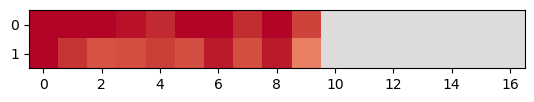

In [178]:
plt.imshow(_fit.beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-10, vmax=10))

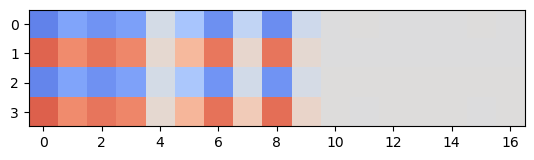

In [179]:
plt.imshow(_fit.residual, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-10, vmax=10))

In [74]:
%autoreload

In [76]:
%timeit model.fit(Y, X)

1.03 ms ± 81.1 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [77]:
%lprun -f sz.depth_model._normal_scaled._fit_normal_scaled_model model.fit(Y, X)

Timer unit: 1e-09 s

Total time: 0.00422866 s
File: /include/StrainZip/src/strainzip/depth_model/_normal_scaled.py
Function: _fit_normal_scaled_model at line 68

Line #      Hits         Time  Per Hit   % Time  Line Contents
    68                                           def _fit_normal_scaled_model(y, X, alpha, maxiter, tol):
    69         1       3406.0   3406.0      0.1      e_edges, s_samples = y.shape
    70         1        572.0    572.0      0.0      e_edges, p_paths = X.shape
    71                                           
    72         1        270.0    270.0      0.0      converged = False
    73         1       1553.0   1553.0      0.0      grad_norm = jnp.inf
    74         1    1395263.0    1e+06     33.0      beta_est = jnp.ones((p_paths, s_samples))
    75         1     333985.0 333985.0      7.9      sigma_est = jnp.ones((1, 1))
    76         1        982.0    982.0      0.0      for i in range(maxiter):
    77         1    1654837.0    2e+06     39.1          b

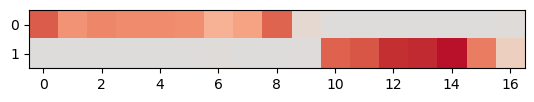

In [60]:
plt.imshow(_fit.beta, cmap='coolwarm', norm=mpl.colors.SymLogNorm(1, vmin=-10, vmax=10))

In [ ]:
from jax import grad

from strainzip.depth_model._normal_scaled3 import _fit_normal_scaled_model

# grad_loglik = grad(loglik, argnums=[0, 1])
# print(grad_loglik(fit.params['beta'], fit.params['sigma'], y, X, alpha=fit.model.alpha))

beta_est, sigma_est = _fit_normal_scaled_model(Y, X, alpha, 100, 1e-3)

loglik(beta_est, sigma_est, Y, X, alpha)

/include/StrainZip/src/strainzip/depth_model/_base.py:143: RuntimeWarning: invalid value encountered in sqrt
  stderr = np.sqrt(np.diag(self.covariance_beta(beta, y, X, **params))).reshape(


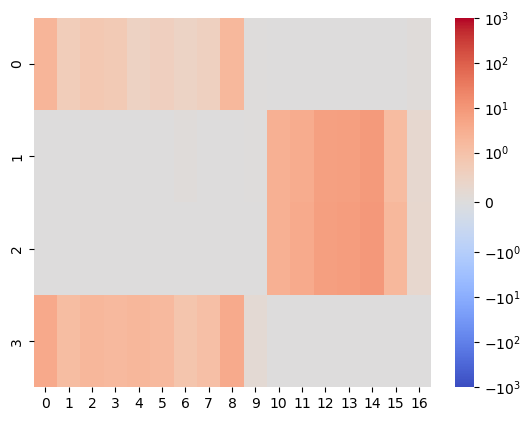

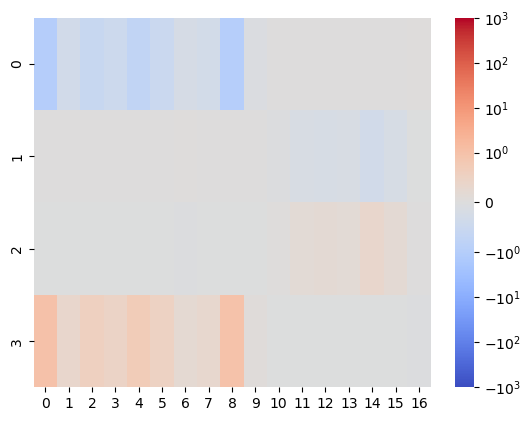

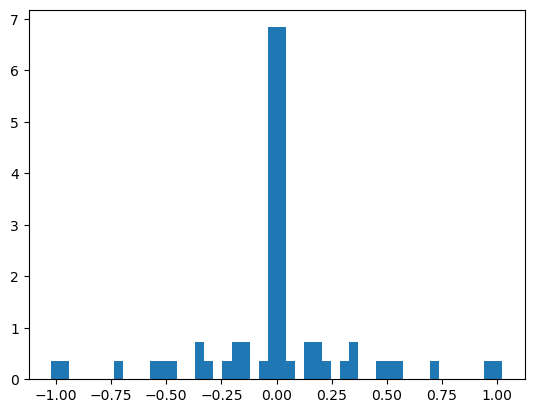

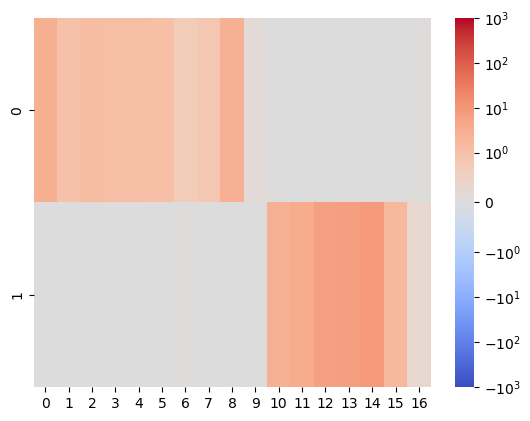

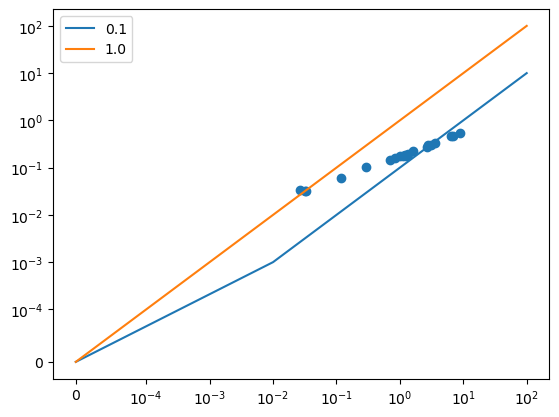

In [395]:
j = 4
fit = _fit

fig = plt.figure()
sns.heatmap(fit.y, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
sns.heatmap(fit.residual, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
plt.hist(fit.residual.flatten(), density=True, bins=50)
# plt.plot(np.linspace(-2, 2), sp.stats.norm(loc=0, scale=fit.params['sigma'].mean()).pdf(np.linspace(-2, 2)))

fig = plt.figure()
sns.heatmap(fit.beta, norm=mpl.colors.SymLogNorm(1, vmin=-1e3, vmax=1e3), cmap='coolwarm')

fig = plt.figure()
plt.scatter(fit.beta, fit.stderr_beta)
xx = np.concatenate([[0], np.logspace(-2, 2)])
plt.plot(xx, xx * 0.1, label=0.1)
plt.plot(xx, xx, label=1.0)
plt.legend()
# plt.plot(xx, (xx + 1) * 0.1)
# plt.plot(xx, (xx + 1) * 0.5)
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('symlog', linthresh=1e-4)


In [329]:
sigma0, sigma1

(0.3311308230507271, 0.7169221585607931)

In [212]:
estimate_sigma_scale(

<function __main__.weighted_least_squares(y, X, W)>

581.9679313501643 PathSet(paths=frozenset({LocalPath(left=0, right=1), LocalPath(left=1, right=0)}), n=2, m=2)
508.7084639340411 PathSet(paths=frozenset({LocalPath(left=1, right=1), LocalPath(left=0, right=0)}), n=2, m=2)
-1090.3239835883453 PathSet(paths=frozenset(), n=2, m=2)


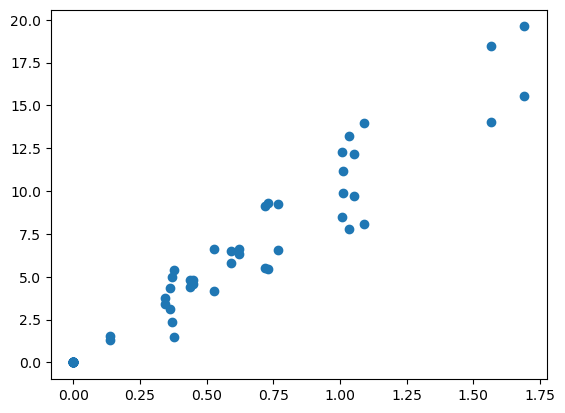

In [86]:
j = 1

(
    fit,
    paths,
    named_paths,
    score_margin,
) = sz.deconvolution.deconvolve_junction_exhaustive(
    problems[j].in_neighbors,
    problems[j].in_flows,
    problems[j].out_neighbors,
    problems[j].out_flows,
    model=model,
    score_name='aic',
    verbose=True
)

x = pd.DataFrame(fit.X @ fit.beta)
y = pd.DataFrame(fit.residual)

plt.scatter(x.stack(), y.stack())

In [ ]:
sz.app.deconvolve._calculate_junction_deconvolution((problems[0], model, 'aic'))

In [ ]:
# Loop over benchmarks
for i, _bench in enumerate(cached_fits[:5]):
    # Loop over a list of models
    for model_name in [
        'Normal',
        'NormalPooled',
        'Laplace',
        'LaplacePooled',
    ]:
        model_class, default_params = sz.depth_model.NAMED_DEPTH_MODELS[model_name]
        model = model_class(**default_params, maxiter=10000)
        fit = model.fit(_bench.y, _bench.X)
        print(model_name, i, fit.get_score('aic'), {False: 'DID NOT CONVERGE', True: ''}[bool(fit.converged)])

In [ ]:
fit.debug['opt1'].iter_num